# Red Wine Quality Classification with Ensemble Models

**Author:** Sabri Hamdaoui

## Project Overview

This project applies ensemble machine learning techniques to classify red wine
quality using physicochemical measurements.

The original numeric wine quality score is converted into three categories:

- **Low:** quality scores 3–4
- **Medium:** quality scores 5–6
- **High:** quality scores 7–8

The project compares Random Forest and Gradient Boosting classifiers using
accuracy, weighted F1 score, train-test generalization gaps, confusion matrices,
and feature importance.

## Dataset Source

The data comes from the UCI Machine Learning Repository's Wine Quality Dataset.
It contains measurements describing red Portuguese Vinho Verde wines.

In [1]:
# ------------------------------------------------
# Imports and project paths
# ------------------------------------------------

from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from sklearn.ensemble import (
    GradientBoostingClassifier,
    RandomForestClassifier,
)
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.model_selection import train_test_split


# Find the repository root reliably
def find_project_root(start_path: Path) -> Path:
    """Find the project root by locating pyproject.toml."""
    for candidate in [start_path, *start_path.parents]:
        if (candidate / "pyproject.toml").exists():
            return candidate

    raise FileNotFoundError(
        "Could not find the project root containing pyproject.toml."
    )


PROJECT_ROOT = find_project_root(Path.cwd())

DATA_PATH = PROJECT_ROOT / "data" / "raw" / "winequality-red.csv"
IMAGES_DIR = PROJECT_ROOT / "docs" / "images"

IMAGES_DIR.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42

print(f"Project root: {PROJECT_ROOT}")
print(f"Dataset path: {DATA_PATH}")
print(f"Dataset exists: {DATA_PATH.exists()}")
print(f"Images folder: {IMAGES_DIR}")

Project root: C:\Repos\ml-05-ensembles
Dataset path: C:\Repos\ml-05-ensembles\data\raw\winequality-red.csv
Dataset exists: True
Images folder: C:\Repos\ml-05-ensembles\docs\images


## 1. Load and Inspect the Data

The dataset is loaded from the project's `data/raw` folder using a semicolon
separator. Initial inspection verifies the dataset dimensions, column types,
missing values, duplicate rows, and sample records before modeling.

In [2]:
# ------------------------------------------------
# Load and inspect the dataset
# ------------------------------------------------

df = pd.read_csv(DATA_PATH, sep=";")

print(f"Dataset shape: {df.shape}")
print(f"Number of rows: {df.shape[0]}")
print(f"Number of columns: {df.shape[1]}")
print(f"Missing values: {df.isna().sum().sum()}")
print(f"Duplicate rows: {df.duplicated().sum()}")

print("\nColumn information:")
df.info()

print("\nFirst five rows:")
display(df.head())

Dataset shape: (1599, 12)
Number of rows: 1599
Number of columns: 12
Missing values: 0
Duplicate rows: 240

Column information:
<class 'pandas.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB

First fi

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


## 2. Clean the Data and Engineer the Target

The dataset contains no missing values, but it includes exact duplicate rows.
These duplicates are removed before the train-test split to reduce the risk of
identical observations appearing in both datasets and inflating model
performance.

The original numeric quality score is converted into three categories:

- **Low:** scores 3–4
- **Medium:** scores 5–6
- **High:** scores 7–8

A numeric target is also created for model training:

- `0` = Low
- `1` = Medium
- `2` = High

In [3]:
# ------------------------------------------------
# Clean duplicates and engineer the target
# ------------------------------------------------

wine_df = df.drop_duplicates().reset_index(drop=True).copy()

rows_removed = len(df) - len(wine_df)

print(f"Original rows: {len(df)}")
print(f"Duplicate rows removed: {rows_removed}")
print(f"Clean rows: {len(wine_df)}")


def quality_to_label(quality: int) -> str:
    """Convert a numeric wine-quality score into a category."""
    if quality <= 4:
        return "Low"
    if quality <= 6:
        return "Medium"
    return "High"


def quality_to_number(quality: int) -> int:
    """Convert a numeric wine-quality score into a model target."""
    if quality <= 4:
        return 0
    if quality <= 6:
        return 1
    return 2


wine_df["quality_label"] = wine_df["quality"].apply(quality_to_label)
wine_df["quality_numeric"] = wine_df["quality"].apply(quality_to_number)

print("\nOriginal quality score counts:")
display(wine_df["quality"].value_counts().sort_index().to_frame("Count"))

print("\nEngineered quality category counts:")
display(
    wine_df["quality_label"]
    .value_counts()
    .reindex(["Low", "Medium", "High"])
    .to_frame("Count")
)

display(wine_df.head())

Original rows: 1599
Duplicate rows removed: 240
Clean rows: 1359

Original quality score counts:


,Count
quality,
3,10
4,53
5,577
6,535
7,167
8,17



Engineered quality category counts:


,Count
quality_label,
Low,63
Medium,1112
High,184


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,quality_label,quality_numeric
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,Medium,1
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,Medium,1
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,Medium,1
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,Medium,1
4,7.4,0.66,0.00,1.8,0.075,13.0,40.0,0.9978,3.51,0.56,9.4,5,Medium,1


## 3. Explore the Target Distribution

The engineered target is substantially imbalanced. Most wines belong to the
Medium category, while the Low category contains relatively few observations.

A stratified train-test split will therefore be used to preserve approximately
the same class proportions in both datasets. Weighted F1 score will also be
reported alongside accuracy.

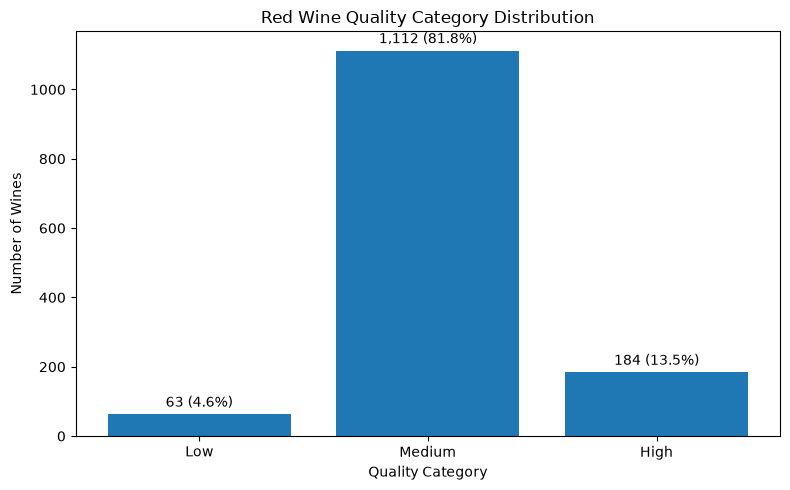

Saved chart: C:\Repos\ml-05-ensembles\docs\images\phase5_class_distribution.png
Chart exists: True


In [4]:
# ------------------------------------------------
# Visualize the engineered target distribution
# ------------------------------------------------

category_order = ["Low", "Medium", "High"]

class_counts = wine_df["quality_label"].value_counts().reindex(category_order)

class_percentages = class_counts / class_counts.sum() * 100

fig, ax = plt.subplots(figsize=(8, 5))

bars = ax.bar(class_counts.index, class_counts.values)

ax.set_title("Red Wine Quality Category Distribution")
ax.set_xlabel("Quality Category")
ax.set_ylabel("Number of Wines")

labels = [
    f"{count:,} ({percentage:.1f}%)"
    for count, percentage in zip(
        class_counts.values,
        class_percentages.values,
        strict=True,
    )
]

ax.bar_label(bars, labels=labels, padding=3)

fig.tight_layout()

distribution_path = IMAGES_DIR / "phase5_class_distribution.png"
fig.savefig(distribution_path, dpi=300, bbox_inches="tight")

plt.show()

print(f"Saved chart: {distribution_path}")
print(f"Chart exists: {distribution_path.exists()}")

## 4. Select Features and Split the Data

All 11 physicochemical measurements are used as input features. The original
`quality` score and both engineered target columns are excluded to prevent
target leakage.

The numeric category column, `quality_numeric`, is used as the target:

- `0` = Low
- `1` = Medium
- `2` = High

The data is divided into 80% training and 20% testing sets. Stratification
preserves the original class proportions in both sets.

Because the Medium class represents most observations, the majority-class
baseline is also calculated. A useful model should improve on this baseline
and demonstrate that it can recognize the minority classes.

In [5]:
# ------------------------------------------------
# Select features and create stratified train/test sets
# ------------------------------------------------

TARGET_COLUMNS = [
    "quality",
    "quality_label",
    "quality_numeric",
]

FEATURE_COLUMNS = [column for column in wine_df.columns if column not in TARGET_COLUMNS]

X = wine_df[FEATURE_COLUMNS]
y = wine_df["quality_numeric"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y,
)

majority_class_baseline = y_test.value_counts(normalize=True).max()

print(f"Number of features: {X.shape[1]}")
print(f"Feature columns: {FEATURE_COLUMNS}")
print(f"Training shape: {X_train.shape}")
print(f"Testing shape: {X_test.shape}")
print(f"Majority-class baseline accuracy: {majority_class_baseline:.4f}")

class_names = {
    0: "Low",
    1: "Medium",
    2: "High",
}

split_distribution = pd.DataFrame(
    {
        "Training Count": y_train.value_counts().sort_index(),
        "Training Percent": (y_train.value_counts(normalize=True).sort_index() * 100),
        "Testing Count": y_test.value_counts().sort_index(),
        "Testing Percent": (y_test.value_counts(normalize=True).sort_index() * 100),
    }
)

split_distribution.index = [class_names[index] for index in split_distribution.index]

display(split_distribution.round(2))

Number of features: 11
Feature columns: ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol']
Training shape: (1087, 11)
Testing shape: (272, 11)
Majority-class baseline accuracy: 0.8162


,Training Count,Training Percent,Testing Count,Testing Percent
Low,50,4.60,13,4.78
Medium,890,81.88,222,81.62
High,147,13.52,37,13.60


## 5. Train and Evaluate the Ensemble Models

Two ensemble approaches are compared:

1. **Random Forest** trains many decision trees independently on different
   samples and combines their predictions. Limiting tree depth can reduce
   overfitting.

2. **Gradient Boosting** builds trees sequentially, with each new tree focusing
   on errors made by the previous ensemble.

Performance is evaluated using train and test accuracy, weighted precision,
weighted recall, weighted F1 score, macro F1 score, and train-test
generalization gaps.

Weighted F1 accounts for class frequency, while macro F1 gives equal importance
to Low, Medium, and High quality categories.

In [6]:
# ------------------------------------------------
# Train and evaluate two ensemble models
# ------------------------------------------------

models = {
    "Random Forest (200, max_depth=10)": RandomForestClassifier(
        n_estimators=200,
        max_depth=10,
        random_state=RANDOM_STATE,
        n_jobs=-1,
    ),
    "Gradient Boosting (100)": GradientBoostingClassifier(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=3,
        random_state=RANDOM_STATE,
    ),
}

results = []
trained_models = {}
test_predictions = {}


def evaluate_model(name, model):
    """Train one model and return its performance measurements."""
    model.fit(X_train, y_train)

    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    train_accuracy = accuracy_score(y_train, y_train_pred)
    test_accuracy = accuracy_score(y_test, y_test_pred)

    train_f1 = f1_score(
        y_train,
        y_train_pred,
        average="weighted",
        zero_division=0,
    )
    test_f1 = f1_score(
        y_test,
        y_test_pred,
        average="weighted",
        zero_division=0,
    )

    results.append(
        {
            "Model": name,
            "Train Accuracy": train_accuracy,
            "Test Accuracy": test_accuracy,
            "Accuracy Gap": train_accuracy - test_accuracy,
            "Test Precision": precision_score(
                y_test,
                y_test_pred,
                average="weighted",
                zero_division=0,
            ),
            "Test Recall": recall_score(
                y_test,
                y_test_pred,
                average="weighted",
                zero_division=0,
            ),
            "Train Weighted F1": train_f1,
            "Test Weighted F1": test_f1,
            "F1 Gap": train_f1 - test_f1,
            "Test Macro F1": f1_score(
                y_test,
                y_test_pred,
                average="macro",
                zero_division=0,
            ),
        }
    )

    trained_models[name] = model
    test_predictions[name] = y_test_pred


for model_name, model in models.items():
    evaluate_model(model_name, model)

results_df = (
    pd.DataFrame(results)
    .sort_values(
        by=["Test Accuracy", "Test Weighted F1"],
        ascending=False,
    )
    .reset_index(drop=True)
)

print(f"Majority-class baseline accuracy: {majority_class_baseline:.4f}")
display(results_df.round(4))

Majority-class baseline accuracy: 0.8162


,Model,Train Accuracy,Test Accuracy,Accuracy Gap,Test Precision,Test Recall,Train Weighted F1,Test Weighted F1,F1 Gap,Test Macro F1
0,"Random Forest (200, max_depth=10)",0.9696,0.8529,0.1167,0.8042,0.8529,0.9680,0.8241,0.1439,0.4953
1,Gradient Boosting (100),0.9696,0.8456,0.1241,0.8048,0.8456,0.9686,0.8232,0.1454,0.5020


## 6. Inspect Performance by Quality Category

Overall accuracy may be misleading because the Medium category dominates the
dataset. Per-class precision, recall, and F1 scores are therefore examined to
determine whether each model can recognize Low and High quality wines.

Confusion matrices are also used to show which categories are most frequently
confused.


Random Forest (200, max_depth=10) — Per-Class Performance


,precision,recall,f1-score,support
Low,0.0000,0.0000,0.0000,13.0
Medium,0.8699,0.9640,0.9145,222.0
High,0.6923,0.4865,0.5714,37.0


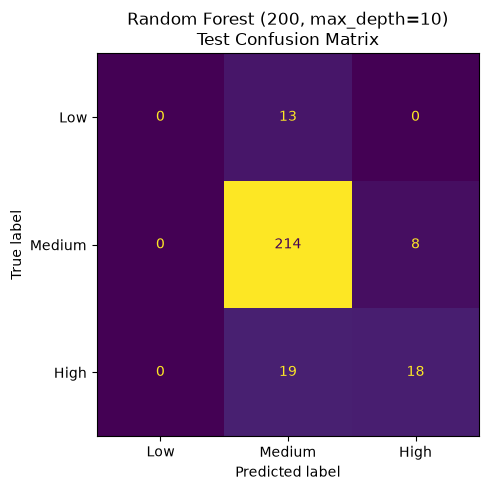

Saved chart: C:\Repos\ml-05-ensembles\docs\images\phase5_confusion_matrix_random_forest.png

Gradient Boosting (100) — Per-Class Performance


,precision,recall,f1-score,support
Low,0.0000,0.0000,0.0000,13.0
Medium,0.8750,0.9459,0.9091,222.0
High,0.6667,0.5405,0.5970,37.0


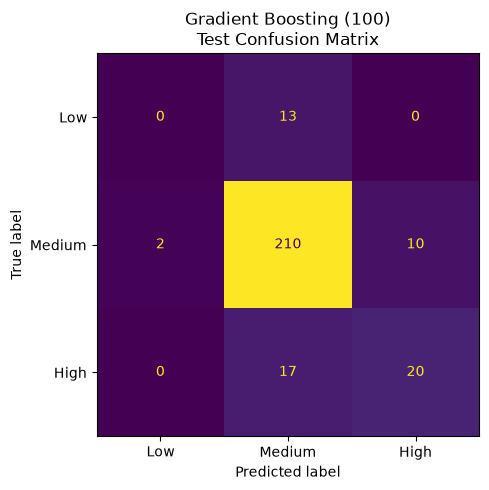

Saved chart: C:\Repos\ml-05-ensembles\docs\images\phase5_confusion_matrix_gradient_boosting.png


In [7]:
# ------------------------------------------------
# Per-class results and confusion matrices
# ------------------------------------------------

from sklearn.metrics import classification_report

target_labels = [0, 1, 2]
target_names = ["Low", "Medium", "High"]

report_tables = {}

image_names = {
    "Random Forest (200, max_depth=10)": ("phase5_confusion_matrix_random_forest.png"),
    "Gradient Boosting (100)": ("phase5_confusion_matrix_gradient_boosting.png"),
}

for model_name in results_df["Model"]:
    predictions = test_predictions[model_name]

    report = classification_report(
        y_test,
        predictions,
        labels=target_labels,
        target_names=target_names,
        output_dict=True,
        zero_division=0,
    )

    report_df = pd.DataFrame(report).transpose()
    report_tables[model_name] = report_df

    print(f"\n{model_name} — Per-Class Performance")

    display(
        report_df.loc[
            target_names,
            ["precision", "recall", "f1-score", "support"],
        ].round(4)
    )

    matrix = confusion_matrix(
        y_test,
        predictions,
        labels=target_labels,
    )

    fig, ax = plt.subplots(figsize=(6, 5))

    display_matrix = ConfusionMatrixDisplay(
        confusion_matrix=matrix,
        display_labels=target_names,
    )

    display_matrix.plot(
        ax=ax,
        values_format="d",
        colorbar=False,
    )

    ax.set_title(f"{model_name}\nTest Confusion Matrix")
    fig.tight_layout()

    image_path = IMAGES_DIR / image_names[model_name]
    fig.savefig(image_path, dpi=300, bbox_inches="tight")

    plt.show()

    print(f"Saved chart: {image_path}")

## 7. Compare Overall Model Performance

Random Forest achieved the highest test accuracy and weighted F1 score.
Gradient Boosting achieved a slightly higher macro F1 score because it
identified more High-quality wines.

However, both models failed to correctly identify any Low-quality wines.
This shows why accuracy alone is insufficient for evaluating this imbalanced
multiclass problem.

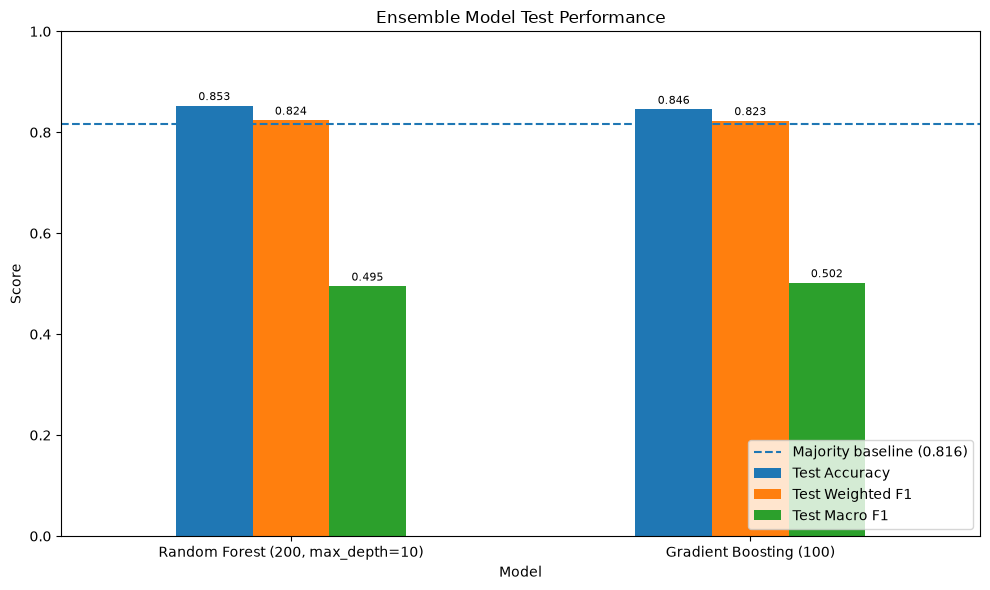

Saved chart: C:\Repos\ml-05-ensembles\docs\images\phase5_model_comparison.png
Chart exists: True


In [8]:
# ------------------------------------------------
# Compare model performance visually
# ------------------------------------------------

comparison_metrics = results_df.set_index("Model")[
    [
        "Test Accuracy",
        "Test Weighted F1",
        "Test Macro F1",
    ]
]

ax = comparison_metrics.plot(
    kind="bar",
    figsize=(10, 6),
)

ax.axhline(
    majority_class_baseline,
    linestyle="--",
    linewidth=1.5,
    label=f"Majority baseline ({majority_class_baseline:.3f})",
)

ax.set_title("Ensemble Model Test Performance")
ax.set_xlabel("Model")
ax.set_ylabel("Score")
ax.set_ylim(0, 1)
ax.tick_params(axis="x", rotation=0)
ax.legend(loc="lower right")

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.3f",
        padding=2,
        fontsize=8,
    )

fig = ax.get_figure()
fig.tight_layout()

comparison_path = IMAGES_DIR / "phase5_model_comparison.png"
fig.savefig(comparison_path, dpi=300, bbox_inches="tight")

plt.show()

print(f"Saved chart: {comparison_path}")
print(f"Chart exists: {comparison_path.exists()}")

## 8. Analyze Feature Importance

Both selected ensemble models provide feature-importance scores. These scores
show which physicochemical measurements contributed most to the models'
decisions.

Feature importance is relative and does not prove that a feature causes wine
quality. However, it helps identify the measurements that the models relied on
most heavily.

Feature importance comparison:


,Feature,Random Forest,Gradient Boosting,Average Importance
0,alcohol,0.1562,0.2133,0.1847
1,volatile acidity,0.1297,0.1438,0.1367
2,sulphates,0.1126,0.1453,0.1290
3,density,0.0880,0.0870,0.0875
4,total sulfur dioxide,0.0780,0.0890,0.0835
5,residual sugar,0.0820,0.0825,0.0822
6,fixed acidity,0.0790,0.0647,0.0718
7,citric acid,0.0798,0.0493,0.0645
8,free sulfur dioxide,0.0621,0.0506,0.0563
9,pH,0.0651,0.0402,0.0526


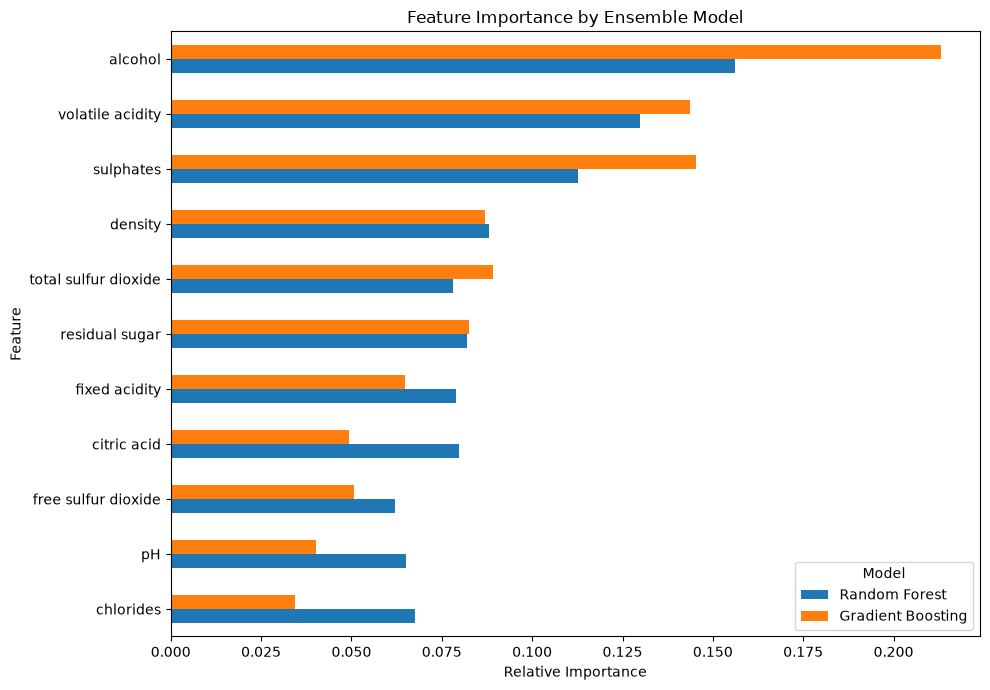

Saved chart: C:\Repos\ml-05-ensembles\docs\images\phase5_feature_importance.png
Chart exists: True


In [9]:
# ------------------------------------------------
# Compare feature importance across both models
# ------------------------------------------------

random_forest_name = "Random Forest (200, max_depth=10)"
gradient_boosting_name = "Gradient Boosting (100)"

feature_importance_df = pd.DataFrame(
    {
        "Feature": FEATURE_COLUMNS,
        "Random Forest": trained_models[random_forest_name].feature_importances_,
        "Gradient Boosting": trained_models[
            gradient_boosting_name
        ].feature_importances_,
    }
)

feature_importance_df["Average Importance"] = feature_importance_df[
    ["Random Forest", "Gradient Boosting"]
].mean(axis=1)

feature_importance_df = feature_importance_df.sort_values(
    by="Average Importance",
    ascending=False,
).reset_index(drop=True)

print("Feature importance comparison:")
display(feature_importance_df.round(4))

plot_order = feature_importance_df.sort_values(
    by="Average Importance",
    ascending=True,
)["Feature"]

plot_data = feature_importance_df.set_index("Feature").loc[
    plot_order, ["Random Forest", "Gradient Boosting"]
]

ax = plot_data.plot(
    kind="barh",
    figsize=(10, 7),
)

ax.set_title("Feature Importance by Ensemble Model")
ax.set_xlabel("Relative Importance")
ax.set_ylabel("Feature")
ax.legend(title="Model")

fig = ax.get_figure()
fig.tight_layout()

importance_path = IMAGES_DIR / "phase5_feature_importance.png"
fig.savefig(importance_path, dpi=300, bbox_inches="tight")

plt.show()

print(f"Saved chart: {importance_path}")
print(f"Chart exists: {importance_path.exists()}")

## 9. Conclusions and Insights

This project applied ensemble machine learning to a new multiclass
classification problem using the UCI Red Wine Quality Dataset.

After removing 240 exact duplicate rows, the analysis used 1,359 unique wine
records and 11 physicochemical input features. The original numeric quality
score was converted into Low, Medium, and High categories.

The target was strongly imbalanced:

- Low: 63 wines, or 4.6%
- Medium: 1,112 wines, or 81.8%
- High: 184 wines, or 13.5%

A stratified 80/20 train-test split preserved these proportions. The
majority-class baseline test accuracy was 0.8162.

### Model Comparison

Random Forest achieved the strongest overall test result:

- Test accuracy: 0.8529
- Test weighted F1: 0.8241
- Test macro F1: 0.4953
- Accuracy generalization gap: 0.1167

Gradient Boosting produced:

- Test accuracy: 0.8456
- Test weighted F1: 0.8232
- Test macro F1: 0.5020
- Accuracy generalization gap: 0.1241

Random Forest is the recommended model because it produced the highest test
accuracy, the highest weighted F1 score, and the smaller generalization gap.
However, its advantage over the majority-class baseline was only about 3.7
percentage points.

Gradient Boosting detected more High-quality wines and achieved a slightly
higher macro F1 score, but its overall accuracy was lower.

### Class-Level Limitation

Neither model correctly identified any Low-quality wine in the test set.
All 13 actual Low-quality wines were classified as Medium.

This is the most important limitation of the project. The relatively high
overall accuracy is driven mainly by strong performance on the dominant Medium
class. Macro F1 and the confusion matrices provide a more complete view than
accuracy alone.

### Feature Importance

The most influential features across the two models were:

1. alcohol
2. volatile acidity
3. sulphates
4. density
5. total sulfur dioxide

These scores describe how the trained models used the features, but they do
not establish causal relationships with wine quality.

### Future Improvements

Possible next steps include:

- collecting more Low-quality examples
- using class weighting or resampling
- tuning tree depth, learning rate, and ensemble size
- comparing cross-validation results instead of relying on one split
- optimizing macro F1 rather than accuracy
- testing alternative category boundaries
- using permutation importance or SHAP for deeper interpretation

Overall, the project demonstrated data cleaning, target engineering,
stratified splitting, ensemble classification, generalization-gap analysis,
class-level evaluation, confusion matrices, and feature-importance analysis.

## 10. Export Project Results

The main model-comparison results, feature-importance values, and class-level
performance metrics are exported to the `artifacts` folder. These files provide
reproducible evidence that can be reviewed without rerunning the notebook.

In [10]:
# ------------------------------------------------
# Export model results and supporting evidence
# ------------------------------------------------

ARTIFACTS_DIR = PROJECT_ROOT / "artifacts"
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)

model_results_path = ARTIFACTS_DIR / "phase5_model_results.csv"
feature_importance_path = ARTIFACTS_DIR / "phase5_feature_importance.csv"
class_results_path = ARTIFACTS_DIR / "phase5_class_performance.csv"

results_df.to_csv(
    model_results_path,
    index=False,
)

feature_importance_df.to_csv(
    feature_importance_path,
    index=False,
)

class_results_frames = []

for model_name, report_df in report_tables.items():
    class_table = (
        report_df.loc[
            target_names,
            ["precision", "recall", "f1-score", "support"],
        ]
        .reset_index()
        .rename(columns={"index": "Quality Category"})
    )

    class_table.insert(0, "Model", model_name)
    class_results_frames.append(class_table)

class_results_df = pd.concat(
    class_results_frames,
    ignore_index=True,
)

class_results_df.to_csv(
    class_results_path,
    index=False,
)

print("Exported project artifacts:")
print(f"- {model_results_path}")
print(f"- {feature_importance_path}")
print(f"- {class_results_path}")

print("\nArtifact verification:")
print(f"Model results exists: {model_results_path.exists()}")
print(f"Feature importance exists: {feature_importance_path.exists()}")
print(f"Class performance exists: {class_results_path.exists()}")

display(results_df.round(4))

Exported project artifacts:
- C:\Repos\ml-05-ensembles\artifacts\phase5_model_results.csv
- C:\Repos\ml-05-ensembles\artifacts\phase5_feature_importance.csv
- C:\Repos\ml-05-ensembles\artifacts\phase5_class_performance.csv

Artifact verification:
Model results exists: True
Feature importance exists: True
Class performance exists: True


,Model,Train Accuracy,Test Accuracy,Accuracy Gap,Test Precision,Test Recall,Train Weighted F1,Test Weighted F1,F1 Gap,Test Macro F1
0,"Random Forest (200, max_depth=10)",0.9696,0.8529,0.1167,0.8042,0.8529,0.9680,0.8241,0.1439,0.4953
1,Gradient Boosting (100),0.9696,0.8456,0.1241,0.8048,0.8456,0.9686,0.8232,0.1454,0.5020
